### program 1

In [21]:
import pandas as pd
data=pd.read_csv("enjoysport.csv")
concepts=data.iloc[:,:-1].values
target = data.iloc[:,-1].values
hypothesis=None

In [22]:
for i in range(len(concepts)):
    if target[i]=="yes":
        if hypothesis is None:
            hypothesis=list(concepts[i])
        else:
            for j in range(len(hypothesis)):
                if hypothesis[j]!=concepts[i][j]:
                    hypothesis[j]="?"             

In [23]:
print("Final hypothesis:")
print(hypothesis)

Final hypothesis:
['sunny', 'warm', '?', 'strong', '?', '?']


### program 2

In [24]:
import pandas as pd
data = pd.read_csv("enjoysport.csv")
concepts = data.iloc[:, :-1].values
target = data.iloc[:, -1].values
s = list(concepts[0])
g = [["?" for i in range(len(s))] for j in range(len(s))]
for i in range(len(concepts)):
    if target[i] == "yes":
        for j in range(len(s)):
            if concepts[i][j] != s[j]:
                s[j] = "?"
                g[j][j] = "?"
    else:
        for j in range(len(s)):
            if concepts[i][j] != s[j]:
                g[j][j] = s[j]
            else:
                g[j][j] = "?"
g_final = []
for G in g:
    if G!=["?"]*len(s):
        g_final.append(G)
print("Specific Hypothesis (S):")
print(s)
print("\nGeneral Hypothesis (G):")
for G in g_final:
    print(G)

Specific Hypothesis (S):
['sunny', 'warm', '?', 'strong', '?', '?']

General Hypothesis (G):
['sunny', '?', '?', '?', '?', '?']
['?', 'warm', '?', '?', '?', '?']


In [27]:
print("version space:")
print(s)
print(g_final)

version space:
['sunny', 'warm', '?', 'strong', '?', '?']
[['sunny', '?', '?', '?', '?', '?'], ['?', 'warm', '?', '?', '?', '?']]


### EXP 2

In [18]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier,AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report
import pandas as pd

In [21]:
iris=load_iris()
df = pd.read_csv('iris.csv')
x,y=iris.data,iris.target

In [4]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

In [11]:
bagging=BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=50,random_state=42)
bagging.fit(x_train,y_train)
y_pred_bagging=bagging.predict(x_test)
bagging_acc=accuracy_score(y_test,y_pred_bagging)

In [12]:
boosting=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),n_estimators=50,algorithm="SAMME",random_state=42)
boosting.fit(x_train,y_train)
y_pred_boosting=boosting.predict(x_test)
boosting_acc=accuracy_score(y_test,y_pred_boosting)

In [13]:
print("Bagging Accuracy:",bagging_acc)
print("Boosting Accuracy:",boosting_acc)
print("\n---bagging Classification Report---")
print(classification_report(y_test,y_pred_bagging,target_names=iris.target_names))
print("\n---Boosting Classification Report---")

Bagging Accuracy: 0.9333333333333333
Boosting Accuracy: 0.9333333333333333

---bagging Classification Report---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45


---Boosting Classification Report---


In [23]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### EXP 3

In [6]:
import pandas as pd
data=[("sparrow","bird",1,1),
     ("eagle","bird",1,1),
     ("penguin","bird",0,0),
     ("bat","mammal",1,1),
     ("cat","mammal",0,1),
     ("butterfly","insect",1,1)]
columns=["name","type","has_wings","can_fly"]
df=pd.DataFrame(data,columns=columns)
print("Dataset:")
print(df)
print("\n CN2-like classification Rules:")
for attribute in ["type","has_wings"]:
    for value in df[attribute].unique():
        subset=df[df[attribute]==value]
        if subset["can_fly"].all():
            print(f"IF {attribute}={value}"
                  f"THEN can_fly=1")

Dataset:
        name    type  has_wings  can_fly
0    sparrow    bird          1        1
1      eagle    bird          1        1
2    penguin    bird          0        0
3        bat  mammal          1        1
4        cat  mammal          0        0
5  butterfly  insect          1        1

 CN2-like classification Rules:
IF type=insectTHEN can_fly=1
IF has_wings=1THEN can_fly=1


In [14]:
import pandas as pd
import math
data=[
    ("sparrow","bird",1,1),
    ("eagle","bird",1,1),
    ("penguin","bird",0,0),
    ("bat","mammal",1,1),
    ("cat","mammal",0,0),
    ("butterfly","insect",1,1)
]
columns=["name","type","has_wings","can_fly"]
df=pd.DataFrame(data,columns=columns)
print("Dataset")
print(df)
facts={}
for _,row in df.iterrows():
    name=row["name"]
    facts[name]=set()
    facts[name].add(f"type({name},{row['type']})")
    if row["has_wings"]==1:
        facts[name].add(f"has_wings({name})")
positive=[]
negative=[]
for _,row in df.iterrows():
    if row["can_fly"]==1:
        positive.append(row["name"])
    else:
        negative.append(row["name"])
print("\n Positive Examples:")
print(positive)
print("\n Negative Examples:")
print(negative)
def satisfied(examples,literal):
    fact=literal.replace("X",examples)
    return fact in facts[examples]
def covered(body,examples):
    result=[]
    for example in examples:
        if all(satisfied(example,literal) for literal in body):
            result.append(example)
    return result
def information_gain(p0,n0,p1,n1,t):
    if p1==0:
        return 0
    before=math.log2(p0/(p0+n0))
    after=math.log2(p1/(p1+n1))
    gain=t*(after-before)
    return gain
def calculate_gain(body,literal,current_positive,current_negative):
    p0=len(current_positive)
    n0=len(current_negative)
    new_body=body+[literal]
    new_positive=covered(new_body,current_positive)
    new_negative=covered(new_body,current_negative)
    p1=len(new_positive)
    n1=len(new_negative)
    t=p1
    gain=information_gain(p0,n0,p1,n1,t)
    return gain,new_positive,new_negative
def foil(positive,negative):
    learned_rules=[]
    uncovered_positive=set(positive)
    while uncovered_positive:
        body=[]
        current_positive=set(uncovered_positive)
        current_negative=set(negative)
        print("\n-----------------------")
        print("Learning a new rule")
        print("\n-----------------------")
        while current_negative:
            candidates=[
                "has_wings(X)",
                "type(X,bird)",
                "type(X,mammal)",
                "type(X,insect)"
            ]
            best_literal=None
            best_gain=float("-inf")
            print("\nCurrent rule body:",body)
            for literal in candidates:
                if literal in body:
                    continue
                gain,new_positive,new_negative=calculate_gain(body,literal,current_positive,current_negative)
                print(f"{literal:20s}"
                  f"Gain={gain:.4f}")
                if gain>best_gain:
                    best_gain=gain
                    best_literal=literal
            if best_literal is None:
                break
            body.append(best_literal)
            current_positive=set(covered(body,current_positive))
            current_negative=set(covered(body,current_negative))
            print("\n Selected literal:",best_literal)
            print("positive covered:",current_positive)
            print("negative covered:",current_negative)
        learned_rules.append(body)
        uncovered_positive-=current_positive
    return learned_rules
rules=foil(positive,negative)
print("\n\n=======================")
print("FINAL FOIL Rules")
print("\n\n=======================")
for i,rule in enumerate(rules,1):
    print(f"Rule{i}:"
          f"can_fly(X):-"
          f"{','.join(rule)}")

Dataset
        name    type  has_wings  can_fly
0    sparrow    bird          1        1
1      eagle    bird          1        1
2    penguin    bird          0        0
3        bat  mammal          1        1
4        cat  mammal          0        0
5  butterfly  insect          1        1

 Positive Examples:
['sparrow', 'eagle', 'bat', 'butterfly']

 Negative Examples:
['penguin', 'cat']

-----------------------
Learning a new rule

-----------------------

Current rule body: []
has_wings(X)        Gain=2.3399
type(X,bird)        Gain=0.0000
type(X,mammal)      Gain=-0.4150
type(X,insect)      Gain=0.5850

 Selected literal: has_wings(X)
positive covered: {'sparrow', 'butterfly', 'eagle', 'bat'}
negative covered: set()


FINAL FOIL Rules


Rule1:can_fly(X):-has_wings(X)


### EXP4

/home/ailab/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fa6e3d92320>
Traceback (most recent call last):
  File "/home/ailab/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/ailab/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/ailab/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/ailab/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", li

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fa6e3d7a290>
Traceback (most recent call last):
  File "/home/ailab/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/ailab/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/ailab/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/ailab/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Cluster Centers
[[5.9016129  2.7483871  4.39354839 1.43387097]
 [5.006      3.428      1.462      0.246     ]
 [6.85       3.07368421 5.74210526 2.07105263]]


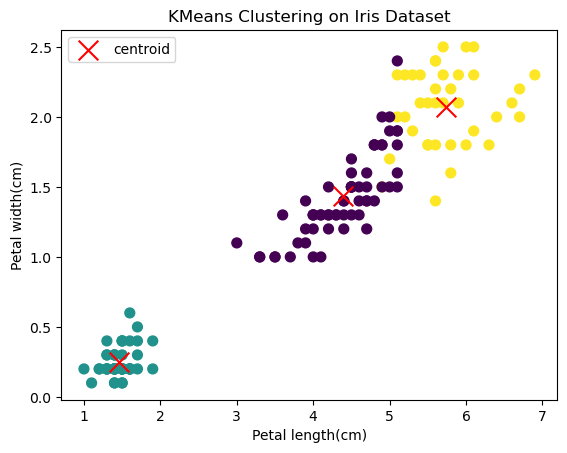

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
iris=load_iris()
data=pd.DataFrame(iris.data,columns=iris.feature_names)
KMeans=KMeans(n_clusters=3,random_state=42)
data['cluster']=KMeans.fit_predict(data)
print("Cluster Centers")
print(KMeans.cluster_centers_)
plt.scatter(data['petal length (cm)'],data['petal width (cm)'],c=data['cluster'],cmap='viridis',s=50)
plt.scatter(KMeans.cluster_centers_[:,2],KMeans.cluster_centers_[:,3],c='red',marker='x',s=200,label='centroid')
plt.xlabel("Petal length(cm)")
plt.ylabel("Petal width(cm)")
plt.title("KMeans Clustering on Iris Dataset")
plt.legend()
plt.show()

### EXP 5

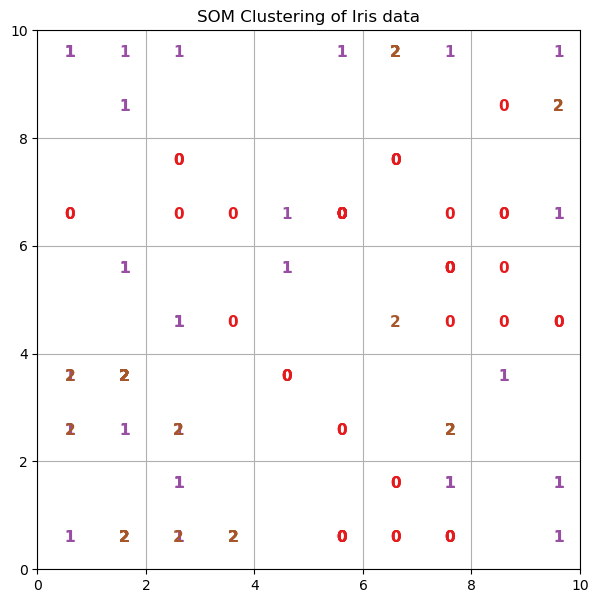

In [11]:
import numpy as np
from minisom import MiniSom
from sklearn import datasets
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
iris=datasets.load_iris()
data=iris.data
target=iris.target
scaler=MinMaxScaler()
data=scaler.fit_transform(data)
som=MiniSom(x=10,y=10,input_len=4,sigma=1.0,learning_rate=0.5)
som.random_weights_init(data)
som.train_random(data,num_iteration=100)
plt.figure(figsize=(7,7))
for i,x in enumerate(data):
    w=som.winner(x)
    plt.text(w[0]+0.5,w[1]+0.5,str(target[i]),color=plt.cm.Set1(target[i]/3),
            fontdict={'weight':'bold','size':11})
plt.title("SOM Clustering of Iris data")
plt.xlim([0,10])
plt.ylim([0,10])
plt.grid()
plt.show()